# Principal Component Analysis (PCA)
## Complete Practical and Mathematical Notebook

**Learning objectives**
- Understand dimensionality reduction and principal components.
- Explain centering, covariance, eigenvectors, eigenvalues, and explained variance.
- Apply PCA with `scikit-learn`.
- Choose components and visualize high-dimensional data.
- Interpret loadings, reconstruction error, and PCA limitations.
- Use PCA safely in a machine-learning pipeline and understand its role in biological data.

PCA is an **unsupervised dimensionality-reduction method**. It does not use class labels to find principal components.

## 1. Why Reduce Dimensionality?

A dataset may contain hundreds or thousands of features. High dimensionality can make visualization difficult, increase computation, and introduce redundant information.

PCA creates a smaller set of new features called **principal components**. The first captures as much variance as possible; each subsequent component captures as much remaining variance as possible while staying orthogonal to previous components.

For $n$ samples and $p$ features:

$$
X \in \mathbb{R}^{n \times p}
$$

PCA can create a lower-dimensional representation:

$$
Z \in \mathbb{R}^{n \times k}, \qquad k < p
$$

## 2. What PCA Does—and Does Not Do

PCA can compress data while retaining variance, help visualize complex datasets, reduce redundancy among correlated features, and serve as preprocessing for some models.

PCA does **not** guarantee better class separation or prediction, identify biologically important features automatically, or discover nonlinear structure in its standard form. A principal component is a mathematical direction, not necessarily an original feature.

## 3. Centering and Standardization

Centering subtracts each feature's mean:

$$
X_{c,ij} = X_{ij} - \mu_j
$$

Standardization additionally divides by its standard deviation:

$$
X_{s,ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
$$

When features use different units or scales, standardization is often appropriate. For a dataset containing age, income, and gene-expression measurements, the numeric scales may differ substantially. Consider the scientific meaning of variance before standardizing every dataset automatically.

## 4. The Covariance Matrix

For centered data, the sample covariance matrix is:

$$
\Sigma = \frac{1}{n-1}X_c^\top X_c
$$

Diagonal entries are feature variances; off-diagonal entries are pairwise covariances. PCA finds orthogonal directions that explain variance in this covariance structure. When features are standardized first, PCA reflects the correlation structure of the standardized features.

## 5. Eigenvectors and Eigenvalues

Principal directions are eigenvectors of the covariance matrix:

$$
\Sigma v_i = \lambda_i v_i
$$

- $v_i$ is an eigenvector: a direction in feature space.
- $\lambda_i$ is its eigenvalue: variance along that direction.

Eigenvalues are ordered from largest to smallest:

$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0
$$

The first component has the largest variance; each later component is orthogonal to earlier components and captures the largest remaining variance. Libraries often use singular value decomposition (SVD), which is numerically robust.

## 6. Explained Variance Ratio

The explained variance ratio for component $i$ is:

$$
r_i = \frac{\lambda_i}{\sum_{j=1}^{p}\lambda_j}
$$

The cumulative explained variance after retaining $k$ components is:

$$
R_k = \sum_{i=1}^{k} r_i
$$

If components explain 55%, 25%, and 10%, the first three together explain 90% of the variance. This does not mean they preserve 90% of predictive performance; it describes variance retained in the PCA representation.

## 7. PCA Workflow

1. Prepare a numeric feature matrix and check missing values.
2. Encode non-numeric variables appropriately.
3. Split training and test data when building a predictive model.
4. Fit scaling and PCA on training data only.
5. Select components based on the task and validation.
6. Transform data using the fitted pipeline.
7. Inspect explained variance and downstream performance.

**Avoid data leakage:** do not fit the scaler or PCA on the test set in a predictive workflow.

## 8. Import Libraries

In [1]:
# Numerical operations and tabular data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Synthetic data, preprocessing, and PCA
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Fixed seed makes the examples reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 9. Create a Synthetic Dataset

We create five-feature data for experimentation. The labels are used only to color plots; they are not passed to PCA.

In [2]:
# Generate 600 samples with five numeric features and four synthetic groups.
X, y = make_blobs(
    n_samples=600,
    n_features=5,
    centers=4,
    cluster_std=2.2,
    random_state=RANDOM_STATE
)

# Use readable names for the feature columns.
feature_names = [f"feature_{i}" for i in range(1, X.shape[1] + 1)]
df = pd.DataFrame(X, columns=feature_names)

# Inspect sample rows and dimensions.
display(df.head())
print("Feature matrix shape:", X.shape)
print("Labels available for visualization:", len(y))

,feature_1,feature_2,feature_3,feature_4,feature_5
0,-10.844467,-7.647110,8.993664,0.753977,-1.538841
1,-8.931054,7.744257,5.710866,-3.226637,-6.114306
2,-9.893676,-9.032548,12.998883,0.254216,7.767509
3,-3.519792,7.144629,6.466618,0.089785,-6.722181
4,-3.005905,9.162848,1.505433,0.775528,-6.635597


Feature matrix shape: (600, 5)
Labels available for visualization: 600


## 10. Explore Features and Correlations

,count,mean,std,min,25%,50%,75%,max
feature_1,600.0,-6.321225,3.410571,-16.057165,-8.640112,-6.486166,-3.946955,2.056684
feature_2,600.0,1.400072,8.205074,-14.170862,-6.451847,1.197669,9.050778,16.301244
feature_3,600.0,4.818461,3.381848,-3.510199,2.436730,5.347646,7.247125,13.047226
feature_4,600.0,-0.546118,3.949601,-12.396145,-3.484551,0.096859,2.381229,10.449179
feature_5,600.0,-3.240366,4.962628,-12.310612,-6.768242,-4.840352,-0.080243,9.720703


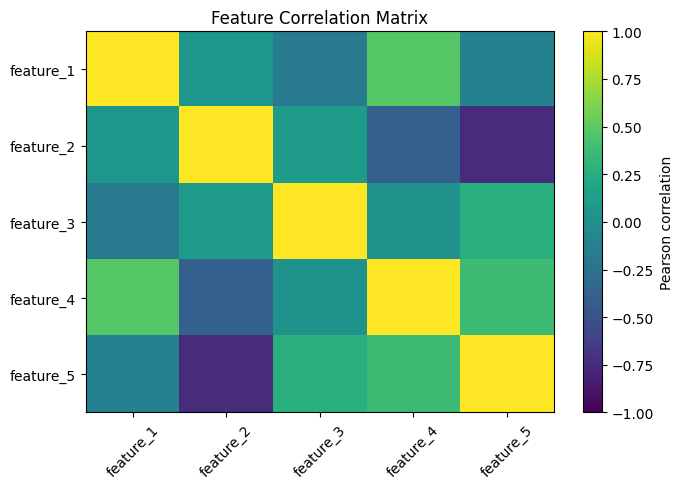

In [3]:
# Summary statistics help reveal the scales and distributions of features.
display(df.describe().T)

# Plot pairwise feature correlations.
correlation_matrix = df.corr()
plt.figure(figsize=(7, 5))
plt.imshow(correlation_matrix, vmin=-1, vmax=1, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(feature_names)), feature_names, rotation=45)
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 11. Standardize Features

Here, each feature is transformed to mean approximately zero and standard deviation approximately one. This is a common choice when feature units are not comparable; real scientific workflows should make this decision deliberately.

In [4]:
# Fit the scaler, then transform the complete synthetic feature matrix.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify the scaled means and standard deviations.
print("Means (approximately 0):", np.round(X_scaled.mean(axis=0), 3))
print("Standard deviations (approximately 1):", np.round(X_scaled.std(axis=0), 3))

Means (approximately 0): [-0.  0.  0. -0.  0.]
Standard deviations (approximately 1): [1. 1. 1. 1. 1.]


## 12. Fit PCA and Inspect Outputs

In [5]:
# Keep all available components so we can inspect their variance contributions.
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

print("Transformed data shape:", X_pca_full.shape)
print("Principal component directions:")
print(np.round(pca_full.components_, 3))
print("Explained variance:")
print(np.round(pca_full.explained_variance_, 4))
print("Explained variance ratios:")
print(np.round(pca_full.explained_variance_ratio_, 4))

Transformed data shape: (600, 5)
Principal component directions:
[[ 0.102 -0.604  0.095  0.488  0.615]
 [ 0.732  0.102 -0.438  0.423 -0.289]
 [ 0.277  0.389  0.832  0.28  -0.014]
 [-0.614  0.178 -0.122  0.71  -0.269]
 [-0.018  0.664 -0.302  0.025  0.683]]
Explained variance:
[2.052  1.4407 0.9893 0.3529 0.1733]
Explained variance ratios:
[0.4097 0.2877 0.1975 0.0705 0.0346]


## 13. Scree Plot and Cumulative Explained Variance

A scree plot shows the variance explained by each component; the cumulative curve shows how much total variance is retained. No single threshold (such as 90% or 95%) is always correct for every application.

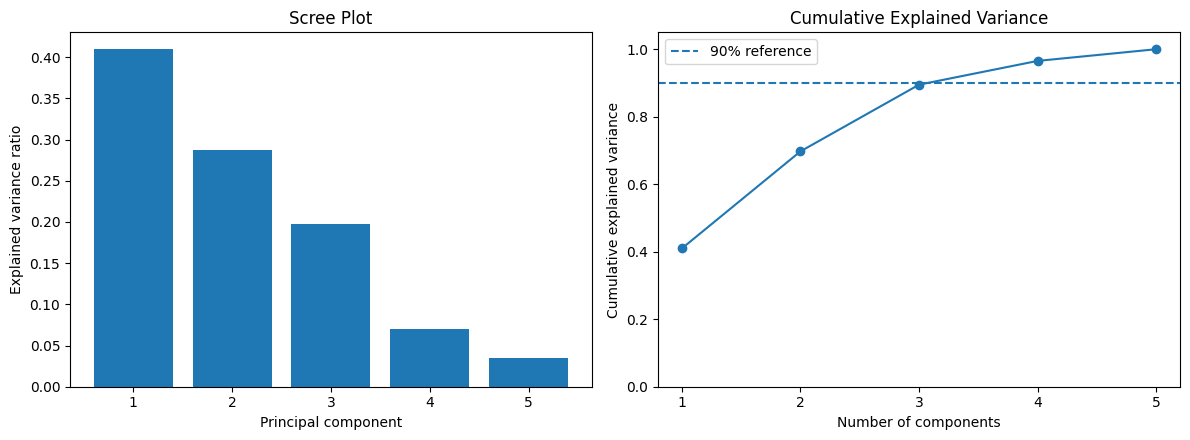

Components needed to reach 90%: 4
Cumulative variance retained: 96.54%


In [6]:
# Calculate individual and cumulative explained variance.
explained_ratio = pca_full.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)
component_numbers = np.arange(1, len(explained_ratio) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot variance explained by each component.
axes[0].bar(component_numbers, explained_ratio)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(component_numbers)

# Plot cumulative variance explained.
axes[1].plot(component_numbers, cumulative_ratio, marker="o")
axes[1].axhline(0.90, linestyle="--", label="90% reference")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_ylim(0, 1.05)
axes[1].set_xticks(component_numbers)
axes[1].legend()

plt.tight_layout()
plt.show()

# Estimate the number of components required to reach 90% variance.
threshold = 0.90
n_components_90 = np.searchsorted(cumulative_ratio, threshold) + 1
print(f"Components needed to reach {threshold:.0%}: {n_components_90}")
print(f"Cumulative variance retained: {cumulative_ratio[n_components_90 - 1]:.2%}")

## 14. Reduce Data to Two Components

`PCA(n_components=2)` learns two principal directions and projects each sample onto them. This is useful for visualization, although a 2D projection can discard substantial information.

In [7]:
# Fit a two-component PCA model and project the standardized samples.
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_2d.shape)
print("Variance explained by two components:",
      f"{pca_2d.explained_variance_ratio_.sum():.2%}")

Original shape: (600, 5)
Reduced shape: (600, 2)
Variance explained by two components: 69.74%


## 15. Visualize the 2D Projection

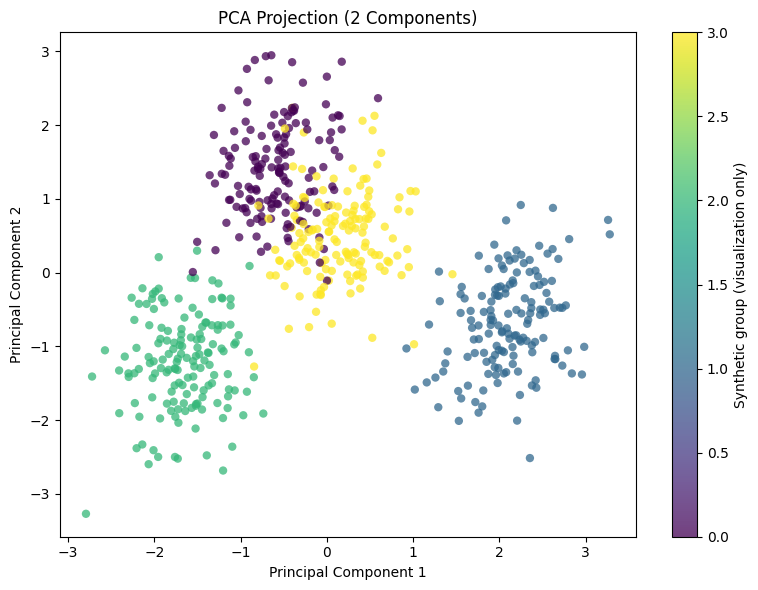

In [8]:
# Labels are used only for plot colors; PCA did not learn from them.
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="viridis",
    alpha=0.75,
    edgecolors="none"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection (2 Components)")
plt.colorbar(scatter, label="Synthetic group (visualization only)")
plt.tight_layout()
plt.show()

## 16. Interpret Component Loadings

`components_` stores component directions. Each row is a component and each column corresponds to an original feature. Coefficient magnitudes can help interpret a component, but signs are relative: reversing the sign of an entire component describes the same axis.

,PC1,PC2
feature_1,0.101660,0.731746
feature_2,-0.604174,0.102042
feature_3,0.094605,-0.438202
feature_4,0.487912,0.422690
feature_5,0.614517,-0.288874


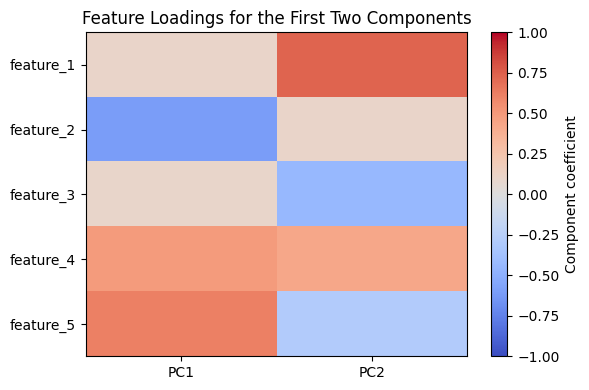

In [9]:
# Arrange the first two component coefficients in a readable table.
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)
display(loadings)

# Plot component coefficients as a heatmap.
plt.figure(figsize=(6, 4))
plt.imshow(loadings, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Component coefficient")
plt.xticks([0, 1], ["PC1", "PC2"])
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature Loadings for the First Two Components")
plt.tight_layout()
plt.show()

## 17. Choose Components by a Variance Threshold

For compatible solvers, a floating-point `n_components` between 0 and 1 asks scikit-learn to retain enough components to reach the specified explained-variance fraction. Treat this as a starting point, not as a replacement for validation.

In [10]:
# Retain enough components to explain at least 95% of the variance.
pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original feature count:", X_scaled.shape[1])
print("Retained component count:", X_pca_95.shape[1])
print("Explained variance retained:",
      f"{pca_95.explained_variance_ratio_.sum():.2%}")

Original feature count: 5
Retained component count: 4
Explained variance retained: 96.54%


## 18. Reconstruct Data and Measure Information Loss

PCA can approximately reconstruct the standardized data from a reduced representation. One simple measure is mean squared reconstruction error:

$$
\operatorname{MSE} = \frac{1}{np}\sum_{i=1}^{n}\sum_{j=1}^{p}
(X_{s,ij} - \hat{X}_{s,ij})^2
$$

Lower error means a closer reconstruction, but not necessarily better predictive performance or greater scientific usefulness.

In [11]:
# Reconstruct the standardized data from its two-component representation.
X_reconstructed = pca_2d.inverse_transform(X_pca_2d)

# Compute mean squared reconstruction error.
reconstruction_mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(f"Reconstruction MSE with 2 components: {reconstruction_mse:.4f}")

Reconstruction MSE with 2 components: 0.3026


## 19. Train/Test Workflow: Avoid Data Leakage

When PCA is used before a supervised model, learn preprocessing steps from the training partition only. A pipeline makes this safer and also supports cross-validation. This example demonstrates transformation only; it does not train a classifier.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Split before fitting any transformations.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

# Scaling and PCA will be fitted using training data only.
pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95))
])

# Fit transformations on the training partition.
X_train_pca = pca_pipeline.fit_transform(X_train)

# Apply the fitted transformations to the held-out test partition.
X_test_pca = pca_pipeline.transform(X_test)

print("Training transformed shape:", X_train_pca.shape)
print("Test transformed shape:", X_test_pca.shape)

Training transformed shape: (450, 4)
Test transformed shape: (150, 4)


## 20. PCA in Biological and Medical Data

PCA is used to explore high-dimensional measurements such as gene expression, proteomics, and other omics data.

Typical uses:
- Explore sample similarities and major sources of variation.
- Visualize potential batch effects.
- Flag samples for further quality-control investigation.
- Reduce dimensions before selected downstream analyses.

**Biological cautions**
- A dominant component may reflect batch, platform, tissue composition, or technical variation rather than the biological effect of interest.
- High variance does not automatically mean high biological importance.
- Normalize and transform omics measurements appropriately; raw counts often require domain-specific preprocessing.
- Investigate sample metadata and quality control before interpreting outliers or apparent groups.
- A PCA plot alone is not evidence of a biomarker or clinical conclusion.

## 21. Gene-Expression-Style Example (Synthetic Only)

The following example creates artificial sample-by-gene measurements to demonstrate data orientation and PCA. It is **not real patient data** and does not represent a particular disease.

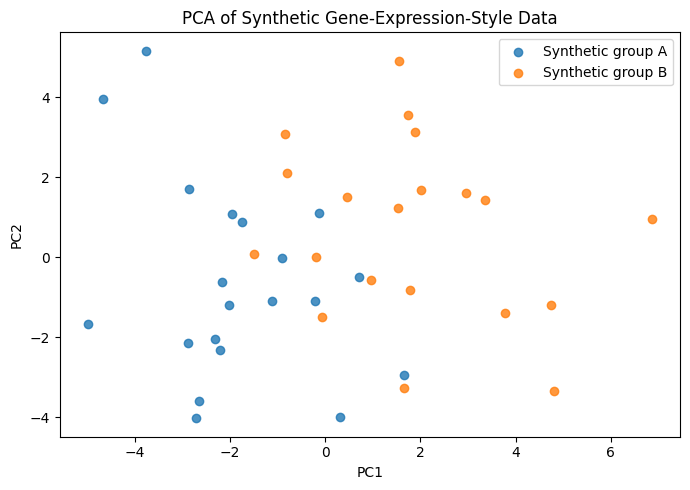

In [13]:
# Create 40 synthetic samples and 100 gene-like features.
rng = np.random.default_rng(RANDOM_STATE)
n_samples = 40
n_genes = 100
group = np.repeat([0, 1], n_samples // 2)

# Simulate background expression-like measurements.
expression = rng.normal(0.0, 1.0, size=(n_samples, n_genes))

# Add a simulated group-associated shift to the first 10 features.
expression[group == 1, :10] += 1.2

# Standardize each feature across samples and project samples into 2D.
expression_scaled = StandardScaler().fit_transform(expression)
expression_pca = PCA(n_components=2).fit_transform(expression_scaled)

# Visualize samples using the simulated group labels only for color.
plt.figure(figsize=(7, 5))
for group_id, label in [(0, "Synthetic group A"), (1, "Synthetic group B")]:
    mask = group == group_id
    plt.scatter(
        expression_pca[mask, 0],
        expression_pca[mask, 1],
        label=label,
        alpha=0.8
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Synthetic Gene-Expression-Style Data")
plt.legend()
plt.tight_layout()
plt.show()

## 22. PCA Compared with Related Methods

| Method | Main purpose | Core idea | Important limitation |
|---|---|---|---|
| PCA | Dimensionality reduction | Linear directions of maximum variance | Can miss nonlinear structure |
| K-Means | Clustering | Assign samples to centroids | Requires choosing $k$; favors roughly spherical groups |
| Hierarchical clustering | Hierarchical grouping | Build a tree of sample similarities | Sensitive to distance and linkage choices |
| DBSCAN | Density-based clustering | Find dense regions and noise | Sensitive to `eps` and density variation |
| t-SNE | Nonlinear visualization | Preserve local neighborhoods | Global distances can be misleading |
| UMAP | Nonlinear embedding | Preserve selected neighborhood structure | Settings affect results; axes are not directly interpretable |

PCA is a transformation method, while clustering methods solve a different task. They can be combined, but the resulting workflow should be validated.

## 23. Common Mistakes and Limitations

1. Skipping scaling without considering feature units.
2. Standardizing automatically without considering scientific meaning.
3. Fitting PCA before splitting predictive data, causing leakage.
4. Interpreting PC1 as a target, cause, or directly observed variable.
5. Assuming 95% explained variance guarantees good predictions.
6. Treating component coefficients as causal effects.
7. Ignoring outliers, which can influence covariance and directions.
8. Treating categorical codes as meaningful numeric distances without justification.
9. Forgetting that scikit-learn expects rows as samples and columns as features.
10. Using linear PCA when the goal requires a nonlinear representation.

## 24. PCA Cheat Sheet (`scikit-learn`)

| Expression | Meaning |
|---|---|
| `PCA()` | Keep all components by default |
| `PCA(n_components=2)` | Retain two components |
| `PCA(n_components=0.95)` | Retain enough components for 95% variance with a compatible solver |
| `pca.fit(X)` | Learn principal directions |
| `pca.transform(X)` | Project data using learned directions |
| `pca.fit_transform(X)` | Fit PCA and project data |
| `pca.components_` | Principal directions / component coefficients |
| `pca.explained_variance_` | Variance explained by each component |
| `pca.explained_variance_ratio_` | Fraction of variance explained by each component |
| `pca.n_components_` | Number of retained components after fitting |
| `pca.mean_` | Per-feature mean learned by PCA |
| `pca.inverse_transform(Z)` | Reconstruct an approximation in original feature space |
| `pca.singular_values_` | Singular values for retained components |

## 25. Exercises

1. Change the dataset to 10 features. How does the scree plot change?
2. Compare PCA on raw features with PCA after `StandardScaler`.
3. Find the minimum component count for 80%, 90%, and 95% explained variance.
4. Plot PC1 against PC3 and compare with PC1 against PC2.
5. Compare reconstruction MSE using 1, 2, 3, and all components.
6. Use `loadings["PC1"].abs().sort_values(ascending=False)` to find features with largest absolute coefficients for PC1.
7. Add one feature with a much larger scale and observe the effect of scaling.
8. On a real omics dataset, investigate whether sample batches align with the first two components; do not treat visual alignment alone as proof.
9. Put PCA and a classifier inside a `Pipeline`; compare validation performance with and without PCA.
10. Explain why a low-variance component may still contain useful predictive information.

## 26. Key Takeaways

- PCA is an unsupervised, linear dimensionality-reduction method.
- Principal components are orthogonal directions ordered by explained variance.
- Eigenvalues describe variance along their corresponding eigenvectors.
- Explained variance ratio summarizes variance retained by a projection.
- Scaling choices matter and should reflect the units and scientific context.
- Fit PCA on training data only in predictive workflows.
- For biological data, examine technical and biological sources of variation before interpreting components.
- Select dimensionality based on the task, interpretability, and validation—not only a variance threshold.

## 27. References

- Scikit-learn — PCA documentation: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- Scikit-learn — Decomposition and dimensionality reduction: https://scikit-learn.org/stable/modules/decomposition.html
- Scikit-learn — StandardScaler documentation: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: a review and recent developments. *Philosophical Transactions of the Royal Society A*, 374(2065), 20150202. https://doi.org/10.1098/rsta.2015.0202